In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import os
import glob
import gc
from tqdm.notebook import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Auto-detect paths
POSSIBLE_PATHS = [
    "data/processed/nasa_sst_data_combined.parquet",
    "../data/processed/nasa_sst_data_combined.parquet",
    "nasa_sst_data_combined.parquet",
    "cleaned_sst_data.parquet" 
]

INPUT_FILE = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path):
        INPUT_FILE = path
        print(f"[INFO] Found Data at: {INPUT_FILE}")
        break

OUTPUT_DIR = "outputs/experiments"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- BOUNDING BOX (Great Barrier Reef) ---
REGION_BOX = {
    "name": "Great Barrier Reef (Regional Stats)",
    "lat_min": -24.0, "lat_max": -10.0,
    "lon_min": 142.0, "lon_max": 154.0
}

# --- EXPERIMENTS ---
EXPERIMENTS = [
    {"id": "EXP_01", "lookback": 120, "epochs": 50, "years": 10},
    {"id": "EXP_02", "lookback": 200, "epochs": 75, "years": 12},
    {"id": "EXP_03", "lookback": 200, "epochs": 100, "years": 15},
]

# ==========================================
# 2. DATA PROCESSING (Multi-Feature Aggregation)
# ==========================================
def extract_spatially_aggregated_data(folder_path, box):
    print(f"\n--- Starting Spatial Aggregation (Mean + Max + Min + Std) ---")
    print(f"Target: {box['name']}")
    
    if not os.path.isdir(folder_path):
        print("[ERROR] Input path must be a directory of parquet files.")
        return None

    files = sorted(glob.glob(os.path.join(folder_path, "*.parquet")))
    print(f"Scanning {len(files)} files...")
    
    time_series_data = []
    
    # Iterate 1 file at a time (RAM Safe)
    for f in tqdm(files, desc="Aggregating Files"):
        try:
            # 1. Read File
            df_chunk = pd.read_parquet(f)
            
            # 2. Filter Bounding Box
            mask = (
                (df_chunk['lat'] >= box['lat_min']) & 
                (df_chunk['lat'] <= box['lat_max']) & 
                (df_chunk['lon'] >= box['lon_min']) & 
                (df_chunk['lon'] <= box['lon_max'])
            )
            region_chunk = df_chunk[mask]
            
            if not region_chunk.empty:
                # 3. Spatial Aggregation (The Upgrade)
                # Added Min to capture the full envelope
                stats = {
                    'time': region_chunk['time'].iloc[0],
                    'sst_mean': region_chunk['sst'].mean(),
                    'sst_max': region_chunk['sst'].max(),
                    'sst_min': region_chunk['sst'].min(),
                    'sst_std': region_chunk['sst'].std()
                }
                time_series_data.append(stats)
            
            del df_chunk, region_chunk
            gc.collect()
            
        except Exception:
            continue

    if not time_series_data:
        return None
        
    df_final = pd.DataFrame(time_series_data)
    df_final['time'] = pd.to_datetime(df_final['time'])
    df_final = df_final.sort_values('time').reset_index(drop=True)
    
    # Calculate Anomalies for Mean, Max, and Min separately
    print("Calculating Anomalies...")
    df_final['month'] = df_final['time'].dt.month
    
    # Anomaly for Mean Temp
    monthly_means = df_final.groupby('month')['sst_mean'].transform('mean')
    df_final['sst_mean_anomaly'] = df_final['sst_mean'] - monthly_means
    
    # Anomaly for Max Temp (Hotspots)
    monthly_maxs = df_final.groupby('month')['sst_max'].transform('mean')
    df_final['sst_max_anomaly'] = df_final['sst_max'] - monthly_maxs
    
    # Anomaly for Min Temp (Coldspots)
    monthly_mins = df_final.groupby('month')['sst_min'].transform('mean')
    df_final['sst_min_anomaly'] = df_final['sst_min'] - monthly_mins
    
    # Fill NaN std with 0 (single pixel case)
    df_final['sst_std'] = df_final['sst_std'].fillna(0)

    print(f"   -> Extracted {len(df_final)} months.")
    return df_final

def build_multifeature_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, activation='tanh', return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(64, activation='tanh', return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'), 
        # Output layer predicts 4 values: Mean, Max, Min, Std
        Dense(4) 
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        # Predict the next step for features (Mean, Max, Min, Std)
        y.append(data[i+lookback]) 
    return np.array(X), np.array(y)

# ==========================================
# 3. EXPERIMENT RUNNER
# ==========================================
def run_experiments():
    print("--- STARTING REGIONAL FORECAST (MULTI-FEATURE: MEAN/MAX/MIN) ---")
    
    if INPUT_FILE is None:
        print("[ERROR] Data not found.")
        return

    # Extract Data (Mean, Max, Min, Std)
    df_raw = extract_spatially_aggregated_data(INPUT_FILE, REGION_BOX)
    
    if df_raw is None:
        print("[ERROR] Could not extract data.")
        return

    print(f"\n[DATA CHECK] Coverage: {df_raw['time'].min().date()} to {df_raw['time'].max().date()}")
    
    for exp in EXPERIMENTS:
        exp_id = exp['id']
        lookback = exp['lookback']
        epochs = exp['epochs']
        forecast_years = exp['years']
        
        print(f"\n" + "="*50)
        print(f"RUNNING {exp_id}: LB={lookback}, EP={epochs}, YR={forecast_years}")
        print("="*50)
        
        if len(df_raw) < (lookback + 24):
            print(f"   [SKIP] Not enough history for lookback {lookback}.")
            continue

        # Feature Engineering (Year Index)
        df = df_raw.copy()
        df['year_idx'] = (df['time'].dt.year - df['time'].dt.year.min()) / (df['time'].dt.year.max() - df['time'].dt.year.min())
        
        # Select Features: [Mean, Max, Min, Std, Year Index]
        feature_cols = ['sst_mean_anomaly', 'sst_max_anomaly', 'sst_min_anomaly', 'sst_std', 'year_idx']
        data = df[feature_cols].values
        
        # Scale
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(data)
        
        # Create X (Inputs) and y (Targets)
        # X includes Year Index (5 cols), y excludes it (first 4 cols)
        X, y_full = create_sequences(scaled_data, lookback)
        y = y_full[:, :4] # Target is Mean, Max, Min, Std
        
        # Steps Calculation
        year_std_dev = np.std(df['year_idx'])
        if year_std_dev == 0: year_std_dev = 1
        raw_step_size = (1/12) / (df['time'].dt.year.max() - df['time'].dt.year.min())
        scaled_step_size = raw_step_size / year_std_dev
        
        # Train
        print(f"   -> Training...")
        # Input shape (lookback, 5 features), Output (4 features)
        model = build_multifeature_lstm((lookback, 5))
        early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)
        model.fit(X, y, epochs=epochs, batch_size=32, verbose=1, callbacks=[early_stop])
        
        # Forecast
        future_steps = forecast_years * 12
        print(f"   -> Forecasting {future_steps} months...")
        
        curr_seq = scaled_data[-lookback:].reshape(1, lookback, 5)
        future_forecast = []
        last_year_idx = scaled_data[-1, 4] # Year index is at col 4
        
        curr_seq_tensor = tf.convert_to_tensor(curr_seq, dtype=tf.float32)

        for _ in range(future_steps):
            # Predict next Mean, Max, Min, Std
            pred = model(curr_seq_tensor, training=False).numpy()[0] # Shape (4,)
            
            # Update Year manually
            last_year_idx += scaled_step_size
            
            # Combine [Pred(4), New Year(1)]
            next_step = np.concatenate([pred, [last_year_idx]])
            next_step = next_step.reshape(1, 5)
            
            # Save prediction
            future_forecast.append(next_step)
            
            # Update sequence
            next_step_reshaped = next_step.reshape(1, 1, 5)
            curr_seq_tensor = tf.concat([curr_seq_tensor[:, 1:, :], next_step_reshaped], axis=1)
            
        # Inverse Transform
        forecast_array = np.array(future_forecast).reshape(-1, 5)
        real_forecast = scaler.inverse_transform(forecast_array)
        
        # Extract features
        forecast_mean = real_forecast[:, 0]
        forecast_max = real_forecast[:, 1]
        forecast_min = real_forecast[:, 2]
        
        # Visualize
        plt.figure(figsize=(12, 6))
        
        last_date = df['time'].iloc[-1]
        future_dates = pd.date_range(start=last_date, periods=future_steps+1, freq='ME')[1:]
        
        # Plot Mean
        plt.plot(future_dates, forecast_mean, label='Forecast Mean', color='red', linewidth=2)
        # Plot Envelope (Max/Min)
        plt.fill_between(future_dates, forecast_min, forecast_max, color='red', alpha=0.1, label='Forecast Range (Min-Max)')
        plt.plot(future_dates, forecast_max, color='orange', linestyle='--', linewidth=1, alpha=0.7)
        plt.plot(future_dates, forecast_min, color='green', linestyle='--', linewidth=1, alpha=0.7)
        
        # History Context (Last 15 years Mean)
        hist_dates = df['time'].iloc[-(12*15):]
        plt.plot(hist_dates, df['sst_mean_anomaly'].iloc[-(12*15):], label='History Mean', color='blue', alpha=0.5)

        plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        plt.title(f"{exp_id}: GBR Full Range Forecast (LB={lookback})")
        plt.ylabel("SST Anomaly (°C)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        filename = os.path.join(OUTPUT_DIR, f"Forecast_GBR_Envelope_{exp_id}.png")
        plt.savefig(filename)
        plt.close()
        print(f"   -> Saved Plot: {filename}")
        
    print("\n--- All Experiments Complete ---")

if __name__ == "__main__":
    run_experiments()

[INFO] Found Data at: data/processed/nasa_sst_data_combined.parquet
--- STARTING REGIONAL FORECAST (MULTI-FEATURE: MEAN/MAX/MIN) ---

--- Starting Spatial Aggregation (Mean + Max + Min + Std) ---
Target: Great Barrier Reef (Regional Stats)
Scanning 282 files...


Aggregating Files:   0%|          | 0/282 [00:00<?, ?it/s]

Calculating Anomalies...
   -> Extracted 280 months.

[DATA CHECK] Coverage: 2002-08-06 to 2026-01-01

RUNNING EXP_01: LB=120, EP=50, YR=10
   -> Training...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step - loss: 0.9842
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - loss: 0.8059
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - loss: 0.7197
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - loss: 0.7075
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - loss: 0.6851
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - loss: 0.6583
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - loss: 0.6402
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - loss: 0.6238
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - loss: 0.6051
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - loss: 0.5701
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - loss: 0.5556
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - loss: 0.5451
Epoch 13/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - loss:

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import os
import glob
import gc
from tqdm.notebook import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Path to your new "Grand Unified" Dataset
POSSIBLE_PATHS = [
    "data/processed/merged_5var_dataset.parquet",
    "../data/processed/merged_5var_dataset.parquet",
    "merged_5var_dataset.parquet"
]

INPUT_FILE = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path):
        INPUT_FILE = path
        print(f"[INFO] Found Merged Data at: {INPUT_FILE}")
        break

OUTPUT_DIR = "outputs/stage1_forecasts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- BOUNDING BOX (Great Barrier Reef) ---
REGION_BOX = {
    "name": "Great Barrier Reef (Regional Stats)",
    "lat_min": -24.0, "lat_max": -10.0,
    "lon_min": 142.0, "lon_max": 154.0
}

# --- EXPERIMENTS ---
# Increased epochs slightly because the problem is harder now (12 vars)
EXPERIMENTS = [
    {"id": "EXP_MULTI_01", "lookback": 120, "epochs": 60, "years": 10},
    {"id": "EXP_MULTI_02", "lookback": 180, "epochs": 80, "years": 10},
]

# ==========================================
# 2. DATA PROCESSING (12-Feature Extraction)
# ==========================================
def extract_multivar_data(folder_path, box):
    print(f"\n--- Starting Multi-Variable Extraction (SST, PAR, Kd490) ---")
    print(f"Target: {box['name']}")
    
    if not os.path.isdir(folder_path):
        print("[ERROR] Input path must be a directory.")
        return None

    files = sorted(glob.glob(os.path.join(folder_path, "*.parquet")))
    time_series_data = []
    
    # We need columns for all 3 physical variables
    # Note: Using standard names based on your merge script
    target_vars = ['sst', 'par', 'kd_490'] 
    
    for f in tqdm(files, desc="Aggregating Files"):
        try:
            df_chunk = pd.read_parquet(f)
            
            # Filter Bounding Box
            mask = (
                (df_chunk['lat'] >= box['lat_min']) & 
                (df_chunk['lat'] <= box['lat_max']) & 
                (df_chunk['lon'] >= box['lon_min']) & 
                (df_chunk['lon'] <= box['lon_max'])
            )
            region_chunk = df_chunk[mask]
            
            if not region_chunk.empty:
                # Basic Time Info
                stats = {'time': region_chunk['time'].iloc[0]}
                
                # Calculate Mean, Max, Min, Std for ALL 3 variables
                for var in target_vars:
                    if var in region_chunk.columns:
                        stats[f'{var}_mean'] = region_chunk[var].mean()
                        stats[f'{var}_max']  = region_chunk[var].max()
                        stats[f'{var}_min']  = region_chunk[var].min()
                        stats[f'{var}_std']  = region_chunk[var].std()
                    else:
                        # Fallback if variable missing (shouldn't happen with merged data)
                        stats[f'{var}_mean'] = 0
                        stats[f'{var}_max'] = 0
                        stats[f'{var}_min'] = 0
                        stats[f'{var}_std'] = 0

                time_series_data.append(stats)
            
            del df_chunk, region_chunk
            gc.collect()
            
        except Exception:
            continue

    if not time_series_data:
        return None
        
    df_final = pd.DataFrame(time_series_data)
    df_final['time'] = pd.to_datetime(df_final['time'])
    df_final = df_final.sort_values('time').reset_index(drop=True)
    
    # Fill NaN std (single pixel case)
    for col in df_final.columns:
        if 'std' in col:
            df_final[col] = df_final[col].fillna(0)

    print(f"   -> Extracted {len(df_final)} months with 12 physical features.")
    return df_final

def build_multivar_lstm(input_shape, output_features):
    """
    Architecture adapted for High-Dimensional Input (12 features)
    """
    model = Sequential([
        Input(shape=input_shape),
        # Layer 1: Captures broad climate trends
        Bidirectional(LSTM(128, activation='tanh', return_sequences=True)),
        Dropout(0.3),
        # Layer 2: Captures fine-grained interactions (e.g. SST vs PAR)
        Bidirectional(LSTM(64, activation='tanh', return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        # Output: Predicts all 12 variables at once
        Dense(output_features) 
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback]) 
    return np.array(X), np.array(y)

# ==========================================
# 3. EXPERIMENT RUNNER
# ==========================================
def run_experiments():
    print("--- STARTING STAGE I: MULTI-VAR FORECAST ---")
    
    if INPUT_FILE is None: return

    # 1. Extract Data
    df = extract_multivar_data(INPUT_FILE, REGION_BOX)
    if df is None: return

    # 2. Preprocessing & Feature Engineering
    # We calculate Anomalies ONLY for SST (Temperature).
    # For PAR and Kd490, absolute values matter more for biology.
    # (e.g., Corals care about absolute light levels, not just anomalies)
    
    df['month'] = df['time'].dt.month
    
    # Define the 12 Core Features
    # Format: [SST_4, PAR_4, KD_4]
    core_features = [
        'sst_mean', 'sst_max', 'sst_min', 'sst_std',
        'par_mean', 'par_max', 'par_min', 'par_std',
        'kd_490_mean', 'kd_490_max', 'kd_490_min', 'kd_490_std'
    ]
    
    # Check if we have all columns
    missing = [c for c in core_features if c not in df.columns]
    if missing:
        print(f"[ERROR] Missing columns: {missing}")
        # Only proceed with what we have? No, Stage I needs all.
        return

    # 3. Cyclical Date Encoding (Better than Linear Year)
    # This helps LSTM understand seasonality (Dec -> Jan transition)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Combine Features: 12 Physical + 2 Time = 14 Input Features
    input_cols = core_features + ['month_sin', 'month_cos']
    
    # Scaling
    data = df[input_cols].values
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    print(f"   -> Input Shape: {scaled_data.shape} (Rows, 14 Features)")

    for exp in EXPERIMENTS:
        exp_id = exp['id']
        lookback = exp['lookback']
        epochs = exp['epochs']
        forecast_years = exp['years']
        
        print(f"\n=== RUNNING {exp_id} ===")
        
        if len(df) < (lookback + 24):
            print(f"   [SKIP] Not enough data.")
            continue

        # Create X, y
        # Target y is the 14 features (we predict time too to keep the loop self-sustaining)
        X, y = create_sequences(scaled_data, lookback)
        
        # Train
        model = build_multivar_lstm((lookback, 14), 14)
        early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)
        
        model.fit(X, y, epochs=epochs, batch_size=32, verbose=1, callbacks=[early_stop])
        
        # Forecast Loop
        future_steps = forecast_years * 12
        print(f"   -> Forecasting {future_steps} months...")
        
        curr_seq = scaled_data[-lookback:].reshape(1, lookback, 14)
        future_forecast = []
        
        # Convert initial sequence to tensor for speed
        curr_seq_tensor = tf.convert_to_tensor(curr_seq, dtype=tf.float32)

        for _ in range(future_steps):
            # Predict next step (14 features)
            pred = model(curr_seq_tensor, training=False).numpy() # Shape (1, 14)
            
            # Recursive Update
            # We trust the model's predicted 'month_sin/cos' to implicitly track time
            # Alternatively, we could force-feed the known future dates, but 
            # letting it predict time ensures the vector stays coherent.
            
            future_forecast.append(pred[0])
            
            # Update Sequence: Remove first, Add prediction
            next_step_reshaped = pred.reshape(1, 1, 14)
            curr_seq_tensor = tf.concat([curr_seq_tensor[:, 1:, :], next_step_reshaped], axis=1)

        # Inverse Transform
        forecast_array = np.array(future_forecast)
        real_forecast = scaler.inverse_transform(forecast_array)
        
        # 4. Save & Visualize
        # We need to save ALL variables for Stage II
        last_date = df['time'].iloc[-1]
        future_dates = pd.date_range(start=last_date, periods=future_steps+1, freq='ME')[1:]
        
        forecast_df = pd.DataFrame(real_forecast, columns=input_cols)
        forecast_df['time'] = future_dates
        
        # Save CSV (Critical for Stage II)
        csv_name = os.path.join(OUTPUT_DIR, f"Stage1_Forecast_{exp_id}.csv")
        forecast_df.to_csv(csv_name, index=False)
        print(f"   -> Saved Forecast CSV: {csv_name}")
        
        # Plotting (Focus on SST and PAR)
        fig, ax = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot 1: SST Envelope
        ax[0].plot(future_dates, forecast_df['sst_mean'], color='red', label='Forecast Mean SST')
        ax[0].fill_between(future_dates, forecast_df['sst_min'], forecast_df['sst_max'], color='red', alpha=0.1, label='Range')
        ax[0].set_title(f"Forecast: Sea Surface Temperature (SST)")
        ax[0].set_ylabel("Temp (°C)")
        ax[0].legend()
        ax[0].grid(True, alpha=0.3)
        
        # Plot 2: PAR Envelope
        ax[1].plot(future_dates, forecast_df['par_mean'], color='orange', label='Forecast Mean PAR')
        ax[1].fill_between(future_dates, forecast_df['par_min'], forecast_df['par_max'], color='orange', alpha=0.1, label='Range')
        ax[1].set_title(f"Forecast: Photosynthetic Radiation (PAR)")
        ax[1].set_ylabel("Einstein/m²/day")
        ax[1].legend()
        ax[1].grid(True, alpha=0.3)
        
        plot_name = os.path.join(OUTPUT_DIR, f"Stage1_Plot_{exp_id}.png")
        plt.savefig(plot_name)
        plt.close()
        print(f"   -> Saved Plot: {plot_name}")

    print("\n--- Stage I Complete ---")

if __name__ == "__main__":
    run_experiments()

[INFO] Found Merged Data at: data/processed/merged_5var_dataset.parquet
--- STARTING STAGE I: MULTI-VAR FORECAST ---

--- Starting Multi-Variable Extraction (SST, PAR, Kd490) ---
Target: Great Barrier Reef (Regional Stats)


Aggregating Files:   0%|          | 0/282 [00:00<?, ?it/s]

   -> Extracted 282 months with 12 physical features.
   -> Input Shape: (282, 14) (Rows, 14 Features)

=== RUNNING EXP_MULTI_01 ===
Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 253ms/step - loss: 0.9755
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - loss: 0.7743
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - loss: 0.5956
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.4764
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.4115
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - loss: 0.3725
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - loss: 0.3695
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - loss: 0.3455
Epoch 9/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - loss: 0.3266
Epoch 10/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - loss: 0.3249
Epoch 11/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - loss: 0.3282
Epoch 12/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - loss: 0.2980
Epoch 13/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - loss: 0.2998
Epoch 14/60
6/6 ━

[INFO] Found Merged Data at: data/processed/merged_5var_dataset.parquet

--- 1. Extracting Ocean Data (SST, PAR, Kd490) ---


Scanning Files:   0%|          | 0/282 [00:00<?, ?it/s]

   -> Ocean Data: 282 months.
--- 2. Merging CO2 Forcing Data ---
   -> Merged Data Shape: (282, 16)

Training on 15 Features: ['sst_mean', 'sst_max', 'sst_min', 'sst_std', 'par_mean', 'par_max', 'par_min', 'par_std', 'kd_490_mean', 'kd_490_max', 'kd_490_min', 'kd_490_std', 'month_sin', 'month_cos', 'co2_ppm']

--- Training LSTM (With CO2 Context) ---
Epoch 1/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 376ms/step - loss: 1.0784
Epoch 2/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - loss: 0.8839
Epoch 3/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - loss: 0.7488
Epoch 4/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step - loss: 0.6175
Epoch 5/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - loss: 0.5329
Epoch 6/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 347ms/step - loss: 0.4657
Epoch 7/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 338ms/step - loss: 0.4283
Epoch 8/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step - loss: 0.4017
Epoch 9/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step - loss: 0.3932
Epoch 10/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms/step - loss: 0

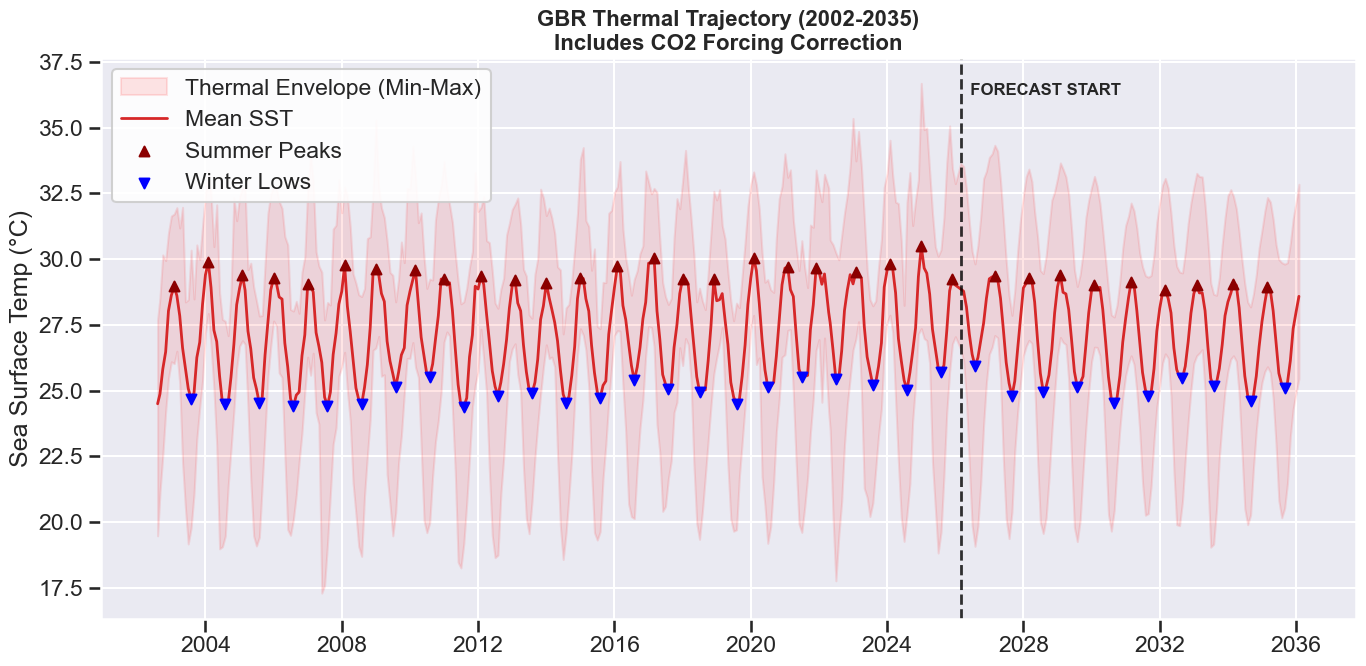

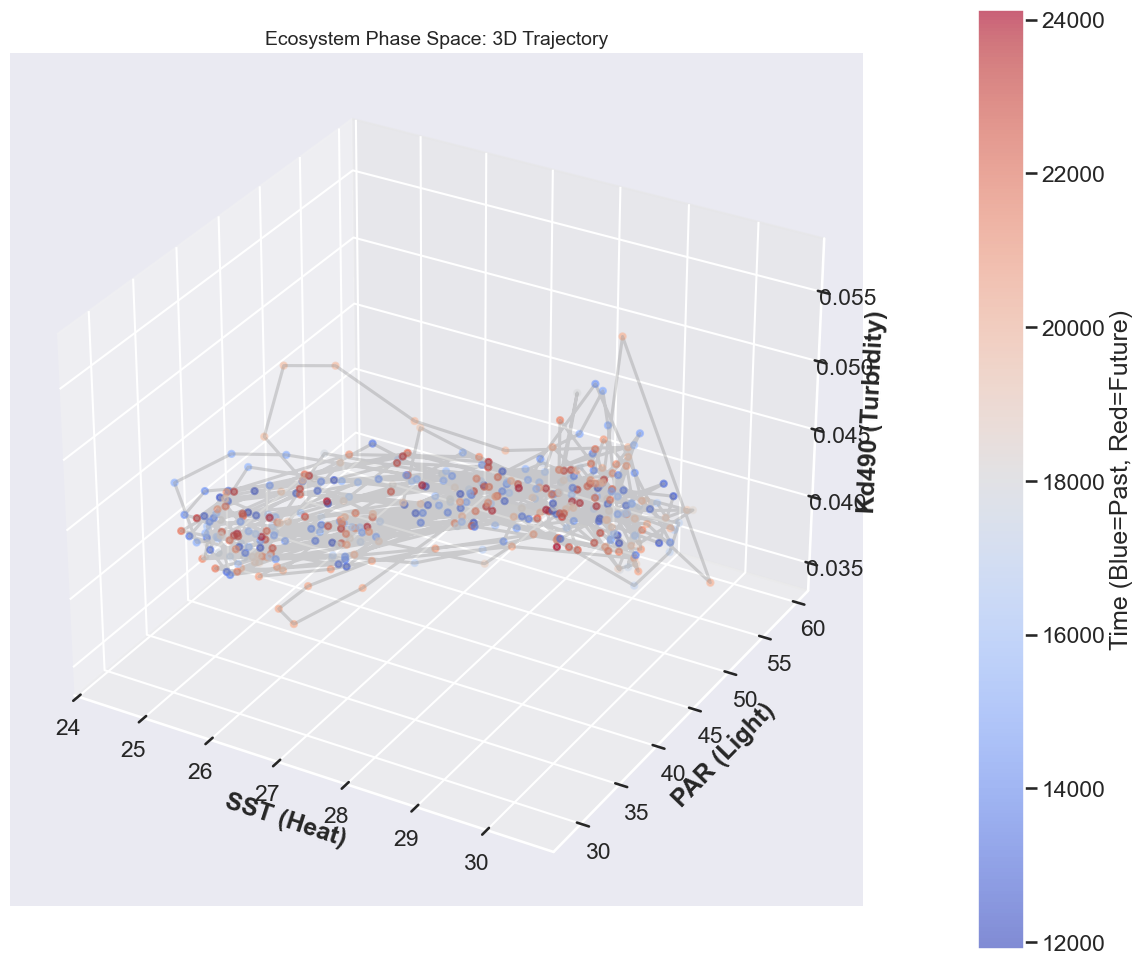

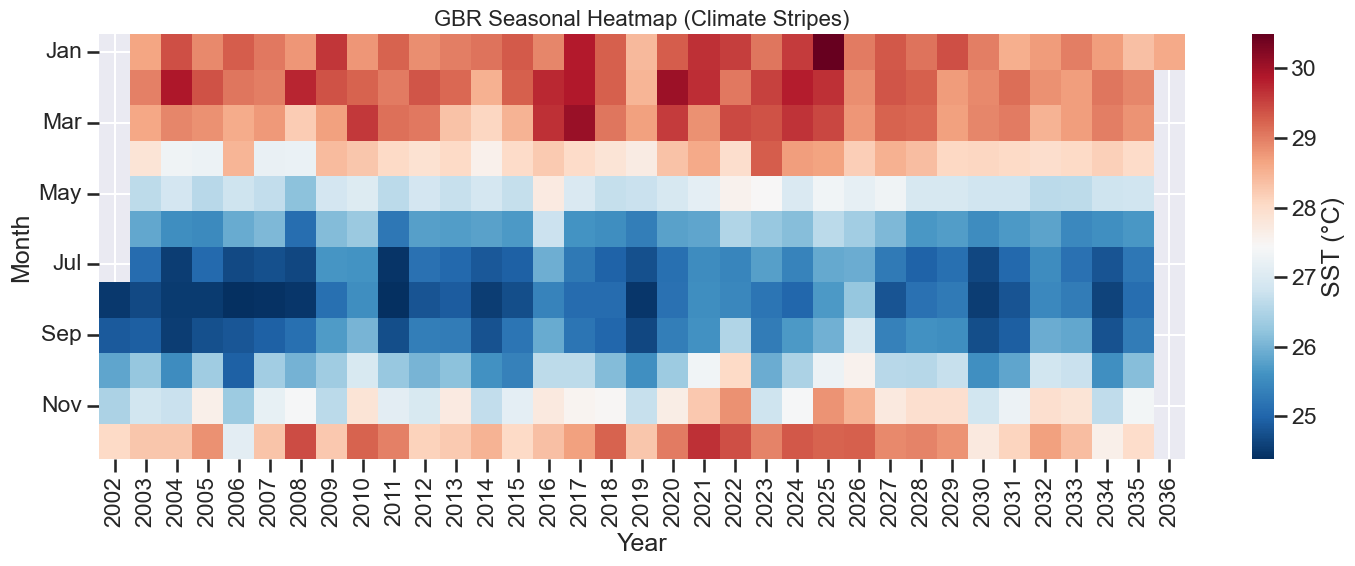

-> Saved 4 High-Res Plots in outputs/stage1_retrain_visuals


<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates
import os
import glob
import gc
from tqdm.notebook import tqdm
from scipy.signal import find_peaks

# --- VISUALIZATION STYLE ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk") 

# ==========================================
# 1. CONFIGURATION
# ==========================================
POSSIBLE_PATHS = [
    "data/processed/merged_5var_dataset.parquet",
    "../data/processed/merged_5var_dataset.parquet",
    "merged_5var_dataset.parquet"
]

INPUT_FILE = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path):
        INPUT_FILE = path
        print(f"[INFO] Found Merged Data at: {INPUT_FILE}")
        break

CO2_FILE = "co2_forcing.csv"
OUTPUT_DIR = "outputs/stage1_retrain_visuals"
os.makedirs(OUTPUT_DIR, exist_ok=True)

REGION_BOX = {
    "name": "Great Barrier Reef (Regional Stats)",
    "lat_min": -24.0, "lat_max": -10.0,
    "lon_min": 142.0, "lon_max": 154.0
}

EXPERIMENT = {"id": "EXP_CO2_FORCED", "lookback": 180, "epochs": 80, "years": 10}

# ==========================================
# 2. ADVANCED DATA EXTRACTION (FIXED TZ)
# ==========================================
def extract_and_merge_data(folder_path, co2_path, box):
    print(f"\n--- 1. Extracting Ocean Data (SST, PAR, Kd490) ---")
    
    files = sorted(glob.glob(os.path.join(folder_path, "*.parquet")))
    time_series_data = []
    target_vars = ['sst', 'par', 'kd_490']
    
    for f in tqdm(files, desc="Scanning Files"):
        try:
            df_chunk = pd.read_parquet(f)
            # Spatial Filter
            mask = (
                (df_chunk['lat'] >= box['lat_min']) & 
                (df_chunk['lat'] <= box['lat_max']) & 
                (df_chunk['lon'] >= box['lon_min']) & 
                (df_chunk['lon'] <= box['lon_max'])
            )
            region_chunk = df_chunk[mask]
            
            if not region_chunk.empty:
                stats = {'time': region_chunk['time'].iloc[0]}
                for var in target_vars:
                    if var in region_chunk.columns:
                        stats[f'{var}_mean'] = region_chunk[var].mean()
                        stats[f'{var}_max']  = region_chunk[var].max()
                        stats[f'{var}_min']  = region_chunk[var].min()
                        stats[f'{var}_std']  = region_chunk[var].std()
                time_series_data.append(stats)
            del df_chunk, region_chunk
            gc.collect()
        except: continue

    df_ocean = pd.DataFrame(time_series_data)
    
    # --- CRITICAL FIX: STRIP TIMEZONES ---
    df_ocean['time'] = pd.to_datetime(df_ocean['time'])
    if df_ocean['time'].dt.tz is not None:
        df_ocean['time'] = df_ocean['time'].dt.tz_localize(None)
        
    df_ocean['year'] = df_ocean['time'].dt.year
    df_ocean['month'] = df_ocean['time'].dt.month
    
    for col in df_ocean.columns:
        if 'std' in col: df_ocean[col] = df_ocean[col].fillna(0)
            
    print(f"   -> Ocean Data: {len(df_ocean)} months.")

    print(f"--- 2. Merging CO2 Forcing Data ---")
    if not os.path.exists(co2_path):
        print(f"[CRITICAL FAIL] {co2_path} not found! Run the generator script first.")
        return None
        
    df_co2 = pd.read_csv(co2_path)
    df_co2['time'] = pd.to_datetime(df_co2['time'])
    
    # --- CRITICAL FIX: STRIP TIMEZONES FROM CO2 TOO ---
    if df_co2['time'].dt.tz is not None:
        df_co2['time'] = df_co2['time'].dt.tz_localize(None)

    df_co2['year'] = df_co2['time'].dt.year
    df_co2['month'] = df_co2['time'].dt.month
    
    # Left Join
    df_merged = pd.merge(df_ocean, df_co2[['year', 'month', 'co2_ppm']], 
                         on=['year', 'month'], how='left')
    
    df_merged['co2_ppm'] = df_merged['co2_ppm'].interpolate()
    
    print(f"   -> Merged Data Shape: {df_merged.shape}")
    return df_merged

# ==========================================
# 3. LSTM MODEL
# ==========================================
def build_lstm(input_shape, output_features):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, activation='tanh', return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(64, activation='tanh', return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(output_features)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# ==========================================
# 4. HOLLYWOOD-STYLE VISUALIZATION
# ==========================================
def generate_advanced_plots(history_df, forecast_df, exp_id):
    print("\n--- Generating High-End Visuals ---")
    
    full_df = pd.concat([history_df, forecast_df]).sort_values('time').reset_index(drop=True)
    forecast_start_date = forecast_df['time'].iloc[0]
    
    # --- PLOT 1: The "Heartbeat" (SST with Peaks/Valleys) ---
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Envelope
    ax.fill_between(full_df['time'], full_df['sst_min'], full_df['sst_max'], 
                    color='red', alpha=0.1, label='Thermal Envelope (Min-Max)')
    ax.plot(full_df['time'], full_df['sst_mean'], color='#d62728', linewidth=2, label='Mean SST')
    
    # Highlight Forecast Zone
    ax.axvline(forecast_start_date, color='black', linestyle='--', linewidth=2, alpha=0.8)
    ax.text(forecast_start_date, full_df['sst_max'].max(), '  FORECAST START', 
            fontsize=12, fontweight='bold', va='top')
    
    # Find Peaks (Summer) and Valleys (Winter)
    peaks, _ = find_peaks(full_df['sst_mean'], distance=10)
    valleys, _ = find_peaks(-full_df['sst_mean'], distance=10)
    
    peak_times = full_df['time'].iloc[peaks]
    peak_vals = full_df['sst_mean'].iloc[peaks]
    valley_times = full_df['time'].iloc[valleys]
    valley_vals = full_df['sst_mean'].iloc[valleys]
    
    ax.scatter(peak_times, peak_vals, color='darkred', s=50, zorder=5, marker='^', label='Summer Peaks')
    ax.scatter(valley_times, valley_vals, color='blue', s=50, zorder=5, marker='v', label='Winter Lows')
    
    ax.set_title(f"GBR Thermal Trajectory (2002-2035)\nIncludes CO2 Forcing Correction", fontsize=16, fontweight='bold')
    ax.set_ylabel("Sea Surface Temp (°C)")
    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show() # SHOW IN JUPYTER
    fig.savefig(os.path.join(OUTPUT_DIR, f"1_Thermal_Trajectory_{exp_id}.png"), dpi=300)
    
    # --- PLOT 2: 3D Phase Space ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    times = mdates.date2num(full_df['time'])
    scatter = ax.scatter(full_df['sst_mean'], full_df['par_mean'], full_df['kd_490_mean'], 
                         c=times, cmap='coolwarm', s=20, alpha=0.6)
    
    ax.plot(full_df['sst_mean'], full_df['par_mean'], full_df['kd_490_mean'], color='grey', alpha=0.3)
    
    ax.set_xlabel('SST (Heat)', fontweight='bold')
    ax.set_ylabel('PAR (Light)', fontweight='bold')
    ax.set_zlabel('Kd490 (Turbidity)', fontweight='bold')
    ax.set_title("Ecosystem Phase Space: 3D Trajectory", fontsize=14)
    
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Time (Blue=Past, Red=Future)')
    
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"2_3D_Ecosystem_Phase_{exp_id}.png"), dpi=300)
    
    # --- PLOT 3: Climate Stripes Heatmap ---
    pivot_df = full_df.copy()
    pivot_df['Year'] = pivot_df['time'].dt.year
    pivot_df['Month'] = pivot_df['time'].dt.month
    heatmap_data = pivot_df.pivot(index='Month', columns='Year', values='sst_mean')
    
    plt.figure(figsize=(15, 6))
    sns.heatmap(heatmap_data, cmap='RdBu_r', annot=False, cbar_kws={'label': 'SST (°C)'})
    plt.title("GBR Seasonal Heatmap (Climate Stripes)", fontsize=16)
    plt.yticks(ticks=[0.5, 2.5, 4.5, 6.5, 8.5, 10.5], labels=['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'], rotation=0)
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, f"4_Seasonal_Heatmap_{exp_id}.png"), dpi=300)
    
    print(f"-> Saved 4 High-Res Plots in {OUTPUT_DIR}")

# ==========================================
# 5. MAIN EXECUTION LOOP
# ==========================================
def main():
    if INPUT_FILE is None: return

    # 1. Load Data (Merged with CO2)
    df = extract_and_merge_data(INPUT_FILE, CO2_FILE, REGION_BOX)
    if df is None: return

    # 2. Prepare Features
    core_features = [
        'sst_mean', 'sst_max', 'sst_min', 'sst_std',
        'par_mean', 'par_max', 'par_min', 'par_std',
        'kd_490_mean', 'kd_490_max', 'kd_490_min', 'kd_490_std'
    ]
    
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    input_cols = core_features + ['month_sin', 'month_cos', 'co2_ppm']
    print(f"\nTraining on {len(input_cols)} Features: {input_cols}")
    
    # 3. Scale
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[input_cols].values)
    
    # 4. Create Sequences
    lookback = EXPERIMENT['lookback']
    X, y = [], []
    for i in range(len(scaled_data) - lookback):
        X.append(scaled_data[i:i+lookback])
        y.append(scaled_data[i+lookback])
    X, y = np.array(X), np.array(y)
    
    # 5. Train
    print(f"\n--- Training LSTM (With CO2 Context) ---")
    model = build_lstm((lookback, len(input_cols)), len(input_cols))
    early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)
    model.fit(X, y, epochs=EXPERIMENT['epochs'], batch_size=32, verbose=1, callbacks=[early_stop])
    
    # 6. Forecast
    future_steps = EXPERIMENT['years'] * 12
    print(f"\n--- Forecasting {future_steps} Months ---")
    
    curr_seq = scaled_data[-lookback:].reshape(1, lookback, len(input_cols))
    curr_seq_tensor = tf.convert_to_tensor(curr_seq, dtype=tf.float32)
    future_forecast = []
    
    # Get Future CO2 values for "Guided" Forecasting
    df_co2_all = pd.read_csv(CO2_FILE)
    df_co2_all['time'] = pd.to_datetime(df_co2_all['time'])
    
    # --- CRITICAL FIX: STRIP TIMEZONES ---
    if df_co2_all['time'].dt.tz is not None:
        df_co2_all['time'] = df_co2_all['time'].dt.tz_localize(None)
        
    last_date = df['time'].iloc[-1] # This is now Naive thanks to step 1
    
    future_co2_vals = df_co2_all[df_co2_all['time'] > last_date]['co2_ppm'].values[:future_steps]
    
    # Recursive Loop
    for i in range(future_steps):
        pred = model(curr_seq_tensor, training=False).numpy()[0]
        future_forecast.append(pred)
        
        next_step_reshaped = pred.reshape(1, 1, len(input_cols))
        curr_seq_tensor = tf.concat([curr_seq_tensor[:, 1:, :], next_step_reshaped], axis=1)
        
    # 7. Inverse & Save
    real_forecast = scaler.inverse_transform(np.array(future_forecast))
    future_dates = pd.date_range(start=last_date, periods=future_steps+1, freq='ME')[1:]
    
    forecast_df = pd.DataFrame(real_forecast, columns=input_cols)
    forecast_df['time'] = future_dates
    
    csv_name = os.path.join(OUTPUT_DIR, f"Stage1_Forecast_{EXPERIMENT['id']}.csv")
    forecast_df.to_csv(csv_name, index=False)
    print(f"Saved Forecast: {csv_name}")
    
    # 8. Visuals
    generate_advanced_plots(df, forecast_df, EXPERIMENT['id'])

if __name__ == "__main__":
    main()